# RFM Clusters

In [48]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


# import built-in package
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")
from fuzzy import rfm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Importing data

In [49]:
order_df = pd.read_csv("../data/processed_data/orders.csv")
item_df = pd.read_csv("../data/processed_data/order_items.csv")

In [50]:
order_df = order_df[["order_id","user_id","items_purchased","price_usd","cogs_usd"]]
order_df = order_df.rename(columns={"items_purchased":"items_in_order","price_usd":"order_price_usd","cogs_usd":"order_cogs_usd"})
order_df

,order_id,user_id,items_in_order,order_price_usd,order_cogs_usd
0,1,20,1,49.99,19.49
1,2,104,1,49.99,19.49
2,3,147,1,49.99,19.49
3,4,160,1,49.99,19.49
4,5,177,1,49.99,19.49
...,...,...,...,...,...
32308,32309,394255,1,49.99,19.49
32309,32310,394257,1,29.99,9.49
32310,32311,394268,2,89.98,31.98
32311,32312,394273,1,29.99,9.49


In [51]:
merged_df = item_df.merge(order_df,on="order_id",how="left")
merged_df

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd,hour,week_day,week_day_name,day,month,month_name,date,user_id,items_in_order,order_price_usd,order_cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49,10,0,Monday,19,3,March,2012-03-19,20,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49,19,0,Monday,19,3,March,2012-03-19,104,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49,6,1,Tuesday,20,3,March,2012-03-20,147,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49,9,1,Tuesday,20,3,March,2012-03-20,160,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49,11,1,Tuesday,20,3,March,2012-03-20,177,1,49.99,19.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40020,40021,2015-03-19 04:10:43,32310,4,1,29.99,9.49,4,3,Thursday,19,3,March,2015-03-19,394257,1,29.99,9.49
40021,40022,2015-03-19 05:27:28,32311,2,1,59.99,22.49,5,3,Thursday,19,3,March,2015-03-19,394268,2,89.98,31.98
40022,40023,2015-03-19 05:27:28,32311,4,0,29.99,9.49,5,3,Thursday,19,3,March,2015-03-19,394268,2,89.98,31.98
40023,40024,2015-03-19 05:35:57,32312,4,1,29.99,9.49,5,3,Thursday,19,3,March,2015-03-19,394273,1,29.99,9.49


In [52]:
# Initialise a df to store the scores for each user id
score_df = pd.DataFrame(merged_df["user_id"].unique())
score_df.columns = ["user_id"]
score_df = score_df.sort_values(by="user_id",ignore_index=True)
score_df

,user_id
0,13
1,20
2,59
3,104
4,147
...,...
31691,394231
31692,394255
31693,394257
31694,394268


# Segmenting customers by RMF scores

## Recency score

In [53]:
# Get the most recent purchase
most_recent = merged_df["date"].max()
# most_recent = merged_df["most_recent_purchase"].max()
recency_df = rfm.calculate_recency(merged_df,most_recent)

# Add recency to score_df
score_df = score_df.merge(recency_df[["user_id","recency"]],on="user_id")
score_df

,user_id,recency
0,13,1058
1,20,1095
2,59,1064
3,104,1095
4,147,1094
...,...,...
31691,394231,0
31692,394255,0
31693,394257,0
31694,394268,0


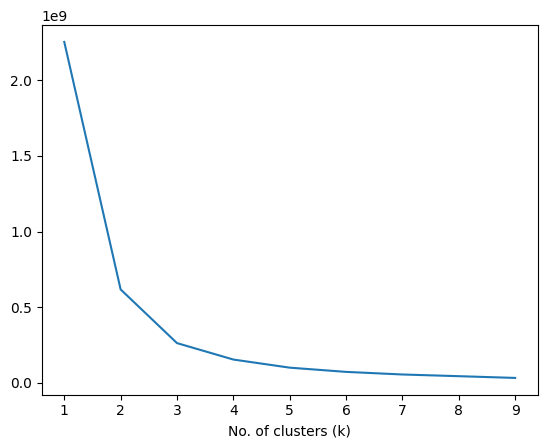

In [54]:
rfm.find_k(score_df,"recency")

- It looks like the optimal k can be either 3 or 4. We can often use business requirements as a guide to select the final k
- We will proceed with k = 4

In [55]:
# Assign the users into 4 clusters based on their recency scores
kmeans = KMeans(n_clusters=4).fit(score_df[["recency"]])
score_df["recency_cluster"] = kmeans.predict(score_df[["recency"]])

In [56]:
score_df = rfm.reorder_cluster(score_df,"recency_cluster","recency",False)
score_df.groupby(by="recency_cluster")["recency"].describe()

,count,mean,std,min,25%,50%,75%,max
recency_cluster,,,,,,,,
0,4227.0,842.723918,98.150262,695.0,764.00,835.0,903.0,1095.0
1,6006.0,547.140526,77.705850,430.0,475.00,539.0,613.0,694.0
2,8880.0,311.066779,64.624417,203.0,255.75,309.0,366.0,429.0
3,12583.0,93.035683,55.843521,0.0,44.00,92.0,136.0,202.0


## Frequency

In [57]:
# Get the number of purchases of each customer
freq_df = rfm.calculate_frequency(merged_df)

# Add recency to score_df
score_df = score_df.merge(freq_df,on="user_id")
score_df

,user_id,recency,recency_cluster,frequency
0,13,1058,0,1
1,20,1095,0,1
2,59,1064,0,1
3,104,1095,0,1
4,147,1094,0,1
...,...,...,...,...
31691,394231,0,3,1
31692,394255,0,3,1
31693,394257,0,3,1
31694,394268,0,3,2


/Users/chaule/Fuzzy_Ecom/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (6) found smaller than n_clusters (7). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/chaule/Fuzzy_Ecom/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (6) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/chaule/Fuzzy_Ecom/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (6) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


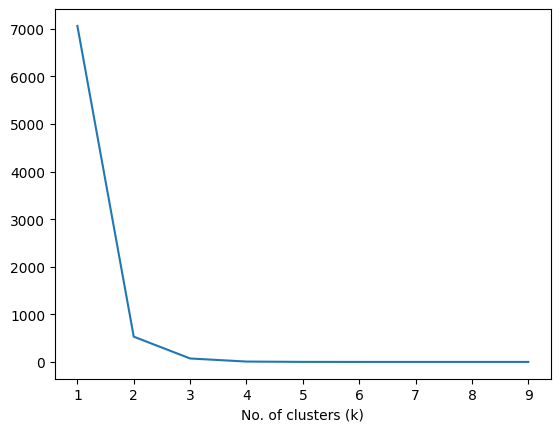

In [58]:
rfm.find_k(score_df,"frequency")

- We go with k = 3

In [59]:
# Assign the users into 3 clusters based on their frequency scores
kmeans = KMeans(n_clusters=3).fit(score_df[["frequency"]])
score_df["frequency_cluster"] = kmeans.predict(score_df[["frequency"]])
score_df = rfm.reorder_cluster(score_df,"frequency_cluster","frequency",True) # ascending = True to make cluster 0 the worse
score_df.groupby(by="frequency_cluster")["frequency"].describe()

,count,mean,std,min,25%,50%,75%,max
frequency_cluster,,,,,,,,
0,23741.0,1.000000,0.000000,1.0,1.0,1.0,1.00,1.0
1,7661.0,2.000000,0.000000,2.0,2.0,2.0,2.00,2.0
2,294.0,3.272109,0.496511,3.0,3.0,3.0,3.75,6.0


## Monetary score

In [70]:
# Calculate monetary
monetary_df = rfm.calculate_monetary(merged_df)

# Add monetary to score_df
score_df = score_df.merge(monetary_df,on="user_id")

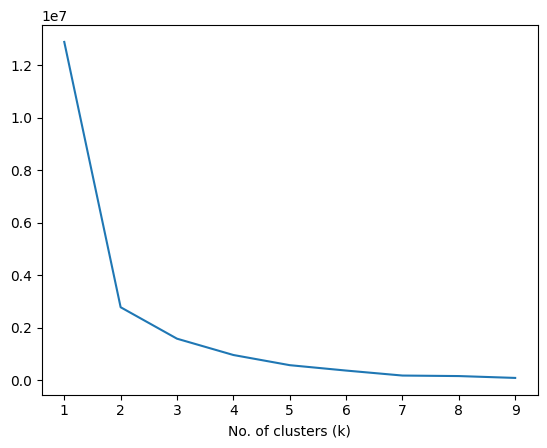

In [77]:
rfm.find_k(score_df,"monetary")

- We select k = 2

In [78]:
# Assign the users into 3 clusters based on their monetary score
kmeans = KMeans(n_clusters=2).fit(score_df[["monetary"]])
score_df["monetary_cluster"] = kmeans.predict(score_df[["monetary"]])
score_df = rfm.reorder_cluster(score_df,"monetary_cluster","monetary",True) # ascending = True to make cluster 0 the worse
score_df.groupby(by="monetary_cluster")["monetary"].describe()

,count,mean,std,min,25%,50%,75%,max
monetary_cluster,,,,,,,,
0,23742.0,49.840367,5.010183,29.0,49.0,49.0,49.0,59.0
1,7954.0,91.011315,16.599585,75.0,79.0,89.0,95.0,251.0


In [ ]:
score_df[["recency","frequency","monetary"]].describe()

,recency,frequency,monetary
count,31696.000000,31696.000000,31696.000000
mean,340.145791,1.262778,61.159444
std,266.684753,0.472040,20.159307
min,0.000000,1.000000,29.990000
25%,111.000000,1.000000,49.990000
50%,282.000000,1.000000,49.990000
75%,506.000000,2.000000,75.980000
max,1095.000000,6.000000,251.940000


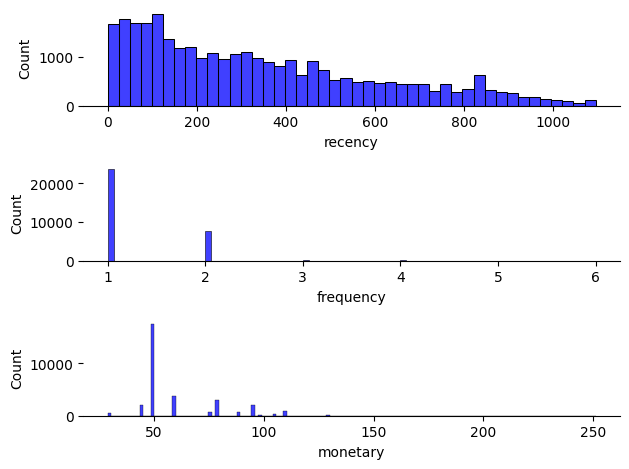

In [79]:
import seaborn as sns
f,ax = plt.subplots(3)

sns.despine(left=True)

sns.histplot(score_df.recency,color="b",ax=ax[0])
sns.histplot(score_df.frequency,color="b",ax=ax[1])
sns.histplot(score_df.monetary,color="b",ax=ax[2])

plt.tight_layout()


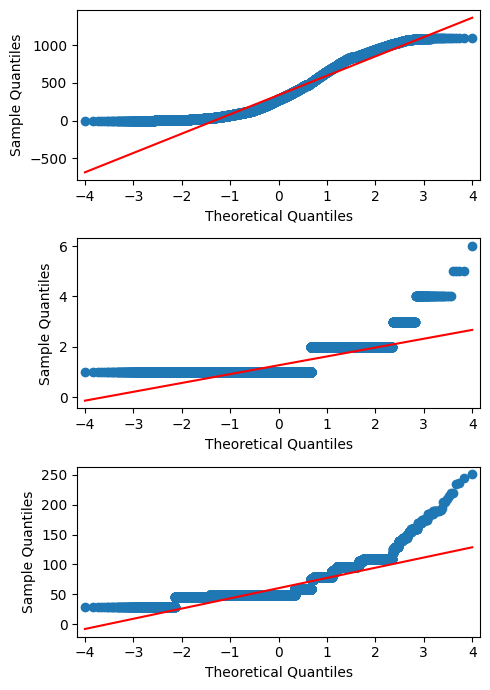

In [80]:
from statsmodels.graphics.gofplots import qqplot
f,ax = plt.subplots(3,1,figsize=(5,7))

qqplot(score_df["recency"],line="r",ax=ax[0],label="recency")
qqplot(score_df.frequency,line="r",ax=ax[1],label="frequency")
qqplot(score_df.monetary,line="r",ax=ax[2],label="monetary")


plt.tight_layout()


- The distributions of all 3 features are not normal
- Therefore we couldn't and shouldn't use statistical methods that assume normal distribution
- This justifies the need for advanced ML models

## Overall RFM score

In [81]:
score_df["rfm"] = score_df["recency_cluster"] + score_df["frequency_cluster"] + score_df["monetary_cluster"]
score_df.groupby("rfm")[["recency","frequency","monetary"]].mean()

,recency,frequency,monetary
rfm,,,
0,843.186769,1.000000,49.802484
1,549.990553,1.000000,50.443667
2,317.433174,1.006478,50.654279
3,105.799373,1.034483,50.938510
4,305.269895,2.002709,88.611243
5,100.048401,2.029751,89.426732
6,87.778409,3.306818,149.352273


- This reveals interesting insights and characteristics of each group
- From this, we segment them into Low/Medium/High value segments based on their rfm score
  - Low: 0 - 2
  - Medium: 3 - 4
  - High: 5 - 6

In [94]:
# Put them into Low/Medium/High value segments based on the overall rfm score
score_df["segment"] = "low"
score_df.loc[score_df["rfm"]>2,"segment"] = "medium"
score_df.loc[score_df["rfm"]>4,"segment"] = "high"
score_df

,user_id,recency,recency_cluster,frequency,frequency_cluster,monetary,monetary_cluster,rfm,segment
0,13,1058,0,1,0,49,0,0,low
1,20,1095,0,1,0,49,0,0,low
2,59,1064,0,1,0,49,0,0,low
3,104,1095,0,1,0,49,0,0,low
4,147,1094,0,1,0,49,0,0,low
...,...,...,...,...,...,...,...,...,...
31691,394231,0,3,1,0,49,0,3,medium
31692,394255,0,3,1,0,49,0,3,medium
31693,394257,0,3,1,0,29,0,3,medium
31694,394268,0,3,2,1,89,1,5,high


In [95]:
segment_order = ["low","medium","high"]
score_df["segment"] = pd.Categorical(score_df["segment"], categories=segment_order, ordered=True)

In [96]:
score_df.groupby("segment")[["recency","frequency","monetary"]].mean()

,recency,frequency,monetary
segment,,,
low,541.329951,1.002410,50.351766
medium,158.172135,1.288699,60.829821
high,99.586966,2.077778,91.680342
